In [ ]:
import json
import os
import random
import string
from pathlib import Path
import csv
from typing import List, Dict

In [ ]:
DATA_DIR = ".././Data"
OUT_DIR = "./processedData"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

LAYMAN_MAP_PATH = "ddxplus/layman_dictionary.json"   # optional
USE_LLM_FOR_LAYMAN = False  # set to True if you will fill the LLM function

In [ ]:
def load_evidence_map(path: str) -> Dict:
    return json.load(open(path))


def map_evidences(evidence_ids: List[str], evidence_map: Dict):
    symptoms, risk_factors, labs = [], [], []

    for evid in evidence_ids:
        if evid not in evidence_map:
            # corrupted or missing ID
            continue
        e = evidence_map[evid]
        name = e.get("name", "").strip().lower()
        typ = e.get("type", "")

        if "symptom" in typ:
            symptoms.append(name)
        elif "risk" in typ:
            risk_factors.append(name)
        elif "lab" in typ:
            labs.append(name)

    return symptoms, risk_factors, labs

In [ ]:
def parse_ddxplus_csv(csv_path: str, evidence_map: Dict):
    records = []

    with open(csv_path, newline='', encoding='utf8') as f:
        reader = csv.DictReader(f)

        for row in reader:
            evid_raw = row["EVIDENCES"].strip()
            evid_list = json.loads(evid_raw.replace("'", '"'))

            symptoms, risks, labs = map_evidences(evid_list, evidence_map)

            # parse differential diagnosis list
            ddx_list = json.loads(row["DIFFERENTIAL_DIAGNOSIS"].replace("'", '"'))

            ddx_list = [
                {"condition": cond, "score": float(score)}
                for cond, score in ddx_list
            ]

            rec = {
                "id": len(records),
                "age": int(row["AGE"]),
                "sex": row["SEX"],
                "final_diagnosis": row["PATHOLOGY"],
                "symptoms": symptoms,
                "risk_factors": risks,
                "labs": labs,
                "raw_evidence_ids": evid_list,
                "differential": ddx_list
            }
            records.append(rec)

    return records


In [ ]:
def inject_typo(word: str) -> str:
    if len(word) < 4:
        return word

    ops = ["insert", "delete", "swap", "replace"]
    op = random.choice(ops)
    i = random.randint(0, len(word)-1)

    if op == "insert":
        return word[:i] + random.choice(string.ascii_lowercase) + word[i:]
    elif op == "delete":
        return word[:i] + word[i+1:]
    elif op == "swap" and i < len(word)-1:
        return word[:i] + word[i+1] + word[i] + word[i+2:]
    elif op == "replace":
        return word[:i] + random.choice(string.ascii_lowercase) + word[i+1:]
    return word


def make_typo_variant(records):
    out = []
    for r in records:
        new_r = r.copy()
        noisy = []
        for s in r["symptoms"]:
            if random.random() < 0.3:  # 30% chance to corrupt
                noisy.append(inject_typo(s))
            else:
                noisy.append(s)
        new_r["symptoms"] = noisy
        out.append(new_r)
    return out

In [ ]:
def make_missinginfo_variant(records):
    out = []
    for r in records:
        new_r = r.copy()
        symptoms = r["symptoms"]
        if len(symptoms) == 0:
            new_r["symptoms"] = symptoms
        else:
            keep_n = max(1, int(len(symptoms) * 0.6))
            new_r["symptoms"] = random.sample(symptoms, keep_n)
        out.append(new_r)
    return out

In [ ]:
NOISE_POOL = [
    "itchy scalp", "hiccups", "toe pain", "mild ankle stiffness", "eye twitch",
    "runny nose", "sneezing", "dandruff", "mild headache", "dry lips",
    "stomach rumbling", "transient dizziness"
]

def make_overcomplete_variant(records):
    out = []
    for r in records:
        new_r = r.copy()
        extra = random.sample(NOISE_POOL, random.randint(2, 4))
        new_r["symptoms"] = r["symptoms"] + extra
        out.append(new_r)
    return out

In [ ]:
def llm_convert_to_layman(text: str) -> str:
    """
    You MUST fill this if USE_LLM_FOR_LAYMAN = True.
    Pseudocode:

    response = openai.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "user",
            "content": f"Rewrite the medical symptom '{text}' into a simple patient-friendly description, 3-8 words, no medical jargon."
        }]
    )
    return response.choices[0].message["content"]
    """
    raise NotImplementedError("LLM API not connected.")


def make_layman_variant(records, layman_dict=None):
    out = []
    for r in records:
        new_r = r.copy()
        new_symptoms = []
        for s in r["symptoms"]:
            if layman_dict and s in layman_dict:
                new_symptoms.append(layman_dict[s])
            else:
                if USE_LLM_FOR_LAYMAN:
                    new_symptoms.append(llm_convert_to_layman(s))
                else:
                    # fallback: simple transformation
                    new_symptoms.append(f"feeling of {s}")
        new_r["symptoms"] = new_symptoms
        out.append(new_r)
    return out

In [ ]:
def write_jsonl(path: str, records: List[Dict]):
    with open(path, "w", encoding="utf8") as f:
        for r in records:
            f.write(json.dumps(r) + "\n")

In [ ]:
print("Loading evidence map...")
evidence_map = load_evidence_map(os.path.join(DATA_DIR, "release_evidences.json"))

In [ ]:
print("Parsing raw DDxPlus CSV...")
csv_path = os.path.join(DATA_DIR, "release_train_patients")  
records = parse_ddxplus_csv(csv_path, evidence_map)

In [ ]:
print("Writing original dataset...")
write_jsonl(os.path.join(OUT_DIR, "ddxplus_original.jsonl"), records)

In [ ]:
print("Generating typo variant...")
typo_variants = make_typo_variant(records)
write_jsonl(os.path.join(OUT_DIR, "ddxplus_typo.jsonl"), typo_variants)

In [ ]:
print("Generating missing-info variant...")
missinginfo_variants = make_missinginfo_variant(records)
write_jsonl(os.path.join(OUT_DIR, "ddxplus_missinginfo.jsonl"), missinginfo_variants)

In [ ]:
print("Generating overcomplete-noise variant...")
overcomplete_variants = make_overcomplete_variant(records)
write_jsonl(os.path.join(OUT_DIR, "ddxplus_overcomplete.jsonl"), overcomplete_variants)

In [ ]:
print("Generating layman-language variant...")
layman_dict = None
if os.path.exists(LAYMAN_MAP_PATH):
    layman_dict = json.load(open(LAYMAN_MAP_PATH))
layman_variants = make_layman_variant(records, layman_dict)
write_jsonl(os.path.join(OUT_DIR, "ddxplus_layman.jsonl"), layman_variants)

In [ ]:
%pip install pandas

In [ ]:
import pandas as pd
import ast

df = pd.read_csv(".././Data/Open-XDDx.csv")

# parse interpretation dict column
df["interpretation_dict"] = df["interpretation"].apply(ast.literal_eval)

# number of diagnoses per case
df["num_diagnoses"] = df["interpretation_dict"].apply(lambda d: len(d))

# flatten diagnoses
df["diagnosis_names"] = df["interpretation_dict"].apply(lambda d: list(d.keys()))


In [ ]:
print("Number of cases:", len(df))

In [ ]:
df.head(1)
print("Interpretation dict example: ", df["interpretation_dict"].iloc[0])
df["interpretation_dict"].iloc[0]

In [ ]:
df.info()

In [ ]:
df.isna().sum()

In [ ]:
df.describe().all()

In [ ]:
df["dict_size"] = df["interpretation_dict"].apply(len)
df[df["dict_size"] != df["disease_num"]]

In [ ]:
df.head()

In [ ]:
import matplotlib.pyplot as plt
df["specialty"].value_counts().plot(kind="bar")
plt.show()
print(df["specialty"].value_counts())

In [ ]:
df["patient_len"] = df["patient_info"].apply(lambda x: len(x.split()))
df["rationale_len"] = df["interpretation"].apply(lambda x: len(x.split()))

In [ ]:
df["patient_len"].hist(bins=30)
df["rationale_len"].hist(bins=30)
plt.show()
print("Patient info length stats:")
print(df["patient_len"].describe())
print("Rationale length stats:")
print(df["rationale_len"].describe())

In [ ]:
rows = []
for idx, row in df.iterrows():
    for dx, symptoms in row["interpretation_dict"].items():
        rows.append({"index": row["Index"], "diagnosis": dx, "num_symptoms": len(symptoms)})
flat = pd.DataFrame(rows)

In [ ]:
flat.head()
flat["num_symptoms"].hist(bins=30)
plt.show()
flat.__len__()
print("Number of symptoms stats:")
print(flat["num_symptoms"].describe())  

In [ ]:
flat["diagnosis"].value_counts().head(20)
flat["diagnosis"].value_counts().tail(20)

In [ ]:
from collections import Counter

symptoms = Counter()
for d in df["interpretation_dict"]:
    for k, v in d.items():
        for s in v:
            symptoms[s] += 1

symptoms_df = pd.DataFrame(symptoms.items(), columns=["symptom", "count"]).sort_values("count", ascending=False)

In [ ]:
symptoms_df.head(20)

In [ ]:
import itertools
from collections import Counter

pair_counter = Counter()

for diags in df["diagnosis_names"]:
    for a, b in itertools.combinations(sorted(diags), 2):
        pair_counter[(a, b)] += 1

pair_df = pd.DataFrame(
    [{"dx1": a, "dx2": b, "count": c} for (a,b),c in pair_counter.items()]
).sort_values("count", ascending=False)


In [ ]:
pair_df.head(20)

In [ ]:
df["difficulty"] = df["num_diagnoses"] * df["patient_len"]
df.sort_values("difficulty", ascending=False).head(10)

In [ ]:
def has_leakage(row):
    text = row["patient_info"].lower()
    for dx in row["diagnosis_names"]:
        if dx.lower() in text:
            return True
    return False

df["leakage"] = df.apply(has_leakage, axis=1)
df["leakage"].sum()

In [ ]:
df[df["leakage"] == True]

In [ ]:
df.groupby("specialty")["num_diagnoses"].mean()
df.groupby("specialty")["diagnosis_names"].apply(lambda x: len(set(sum(x, []))))

In [ ]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from collections import Counter
import re

# Pretty plots
plt.style.use('seaborn-v0_8')

In [ ]:
TRAIN_PATH = ".././Data/release_train_patients."
VAL_PATH = ".././Data/release_validate_patients"
# TEST_PATH = ".././Data/release_test_patients"

COND_PATH = ".././Data/release_conditions.json"
EVID_PATH = ".././Data/release_evidences.json"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
# test_df = pd.read_csv(TEST_PATH)

with open(COND_PATH) as f:
    cond_meta = json.load(f)

with open(EVID_PATH) as f:
    evid_meta = json.load(f)

In [ ]:
def parse_list(x):
    return ast.literal_eval(x) if isinstance(x, str) else x

train_df["DIFFERENTIAL_DIAGNOSIS"] = train_df["DIFFERENTIAL_DIAGNOSIS"].apply(parse_list)
train_df["EVIDENCES"] = train_df["EVIDENCES"].apply(parse_list)


In [ ]:
def split_ev(entry):
    m = re.match(r"(E_\d+)(?:_@_(V_\d+))?", entry)
    return m.group(1), m.group(2) if m and m.group(2) else None

df["EV_PARSED"] = df["EVIDENCES"].apply(lambda lst: [split_ev(e) for e in lst])

In [ ]:
type_counts = {"Binary":0, "Categorical":0, "Multi-choice":0}

for ev, meta in evid_meta.items():
    dt = meta.get("data_type")
    if dt == "B": type_counts["Binary"] += 1
    elif dt == "C": type_counts["Categorical"] += 1
    elif dt == "M": type_counts["Multi-choice"] += 1

evidence_df = pd.DataFrame.from_dict(type_counts, orient="index", columns=["Count"])
evidence_df["Percent"] = (evidence_df["Count"] / evidence_df["Count"].sum() * 100).round(2)
evidence_df


In [ ]:
df["SYMPTOMS"] = df["EV_PARSED"].apply(lambda x: sum(meta.get(code, {}).get("is_antecedent")==False 
                                                     for code,_ in x))
df["ANTECEDENTS"] = df["EV_PARSED"].apply(lambda x: sum(meta.get(code, {}).get("is_antecedent")==True 
                                                       for code,_ in x))
df["TOTAL_EVID"] = df["SYMPTOMS"] + df["ANTECEDENTS"]

print(df[["TOTAL_EVID","SYMPTOMS","ANTECEDENTS"]].describe())


In [ ]:
df["TOTAL_EVID"].plot(kind="hist", bins=30, figsize=(8,4))
plt.title("Distribution of #Evidences per Patient")
plt.xlabel("Evidences")
plt.show()


In [ ]:
df["PATHOLOGY"].value_counts().sort_values(ascending=True).plot(
    kind="barh", figsize=(8,12))
plt.title("Pathologies Distribution")
plt.xlabel("Count")
plt.show()


In [ ]:
df["SEX"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(5,5))
plt.title("Sex Distribution")
plt.ylabel("")
plt.show()


In [ ]:
df["AGE"].plot(kind="hist", bins=[0,1,5,15,30,45,60,75,100], figsize=(8,4))
plt.title("Age Group Distribution")
plt.xlabel("Age")
plt.show()


In [ ]:
df["DDX_LEN"] = df["DIFFERENTIAL_DIAGNOSIS"].apply(len)

df["DDX_LEN"].plot(kind="hist", bins=20, figsize=(8,4))
plt.title("Differential Diagnosis Size Distribution")
plt.xlabel("Number of Conditions in DDx")
plt.show()


In [ ]:
def truth_rank(row):
    for i,(dis,_) in enumerate(row["DIFFERENTIAL_DIAGNOSIS"]):
        if dis == row["PATHOLOGY"]:
            return i+1
    return None

df["TRUTH_RANK"] = df.apply(truth_rank, axis=1)

df["TRUTH_RANK"].value_counts().sort_index().plot(kind="bar", logy=True, figsize=(8,4))
plt.title("Rank of True Pathology in DDx (log scale)")
plt.xlabel("Rank Position")
plt.ylabel("Frequency (log)")
plt.show()

print("Top-1 Match Rate:", (df["TRUTH_RANK"]==1).mean())


In [ ]:
import json
import networkx as nx

# Load JSON metadata
conditions = json.load(open(".././Data/release_conditions.json"))
evidences = json.load(open(".././Data/release_evidences.json"))

KG = nx.DiGraph()

# Add diseases and their evidence relations
for cond_name, meta in conditions.items():
    KG.add_node(cond_name, type="disease")

    # Symptoms edges
    for evid in meta["symptoms"].keys():
        KG.add_node(evid, type="evidence")
        KG.add_edge(evid, cond_name, relation="has_symptom")

    # Antecedents edges
    for evid in meta["antecedents"].keys():
        KG.add_node(evid, type="evidence")
        KG.add_edge(evid, cond_name, relation="risk_factor")


In [ ]:
import pandas as pd, ast
df = pd.read_csv(".././Data/release_train_patients")
df["DIFF"] = df["DIFFERENTIAL_DIAGNOSIS"].apply(ast.literal_eval)

# Co-occurrence edges (optional but good for multi-hop DDx)
for dlist in df["DIFF"]:
    diseases = [d for d,_ in dlist]
    for i in range(len(diseases)):
        for j in range(i+1, len(diseases)):
            KG.add_edge(diseases[i], diseases[j], relation="cooccur")
            KG.add_edge(diseases[j], diseases[i], relation="cooccur")


In [ ]:
print("Total nodes:", KG.number_of_nodes())
print("Total edges:", KG.number_of_edges())

# Check node type distribution
from collections import Counter
print(Counter(nx.get_node_attributes(KG, "type").values()))

In [ ]:
import matplotlib.pyplot as plt

def show_subgraph(center, hops=2):
    nodes = set([center])
    frontier = set([center])

    for _ in range(hops):
        new_f = set()
        for node in frontier:
            new_f.update(KG.predecessors(node))
            new_f.update(KG.successors(node))
        nodes.update(new_f)
        frontier = new_f

    sub = KG.subgraph(nodes)
    pos = nx.spring_layout(sub, seed=42)

    node_colors = ["tomato" if KG.nodes[n]["type"] == "disease" else "skyblue" for n in sub.nodes()]
    nx.draw(sub, pos, with_labels=True, node_color=node_colors, font_size=7, node_size=800)
    plt.show()

show_subgraph("Pneumonia", hops=1)


In [ ]:
def extract_subgraph_for_symptoms(KG, symptoms, hops=1):
    nodes = set(symptoms)
    frontier = set(symptoms)

    for _ in range(hops):
        next_nodes = set()
        for node in frontier:
            next_nodes.update(KG.successors(node))  # symptom → diseases
            next_nodes.update(KG.predecessors(node)) # disease → other evidence
        nodes.update(next_nodes)
        frontier = next_nodes

    return KG.subgraph(nodes)


In [ ]:
def build_llm_context(subgraph, evid_meta):
    diseases = [n for n in subgraph.nodes() if subgraph.nodes[n]["type"] == "disease"]
    evidences = [n for n in subgraph.nodes() if subgraph.nodes[n]["type"] == "evidence"]

    context = []

    for dis in diseases:
        related = {"symptoms": [], "antecedents": []}
        for ev in evidences:
            if subgraph.has_edge(ev, dis):
                rel = subgraph[ev][dis]["relation"]
                ev_name = evid_meta.get(ev, {}).get("question_en", ev)
                if rel == "has_symptom":
                    related["symptoms"].append(ev_name)
                elif rel == "risk_factor":
                    related["antecedents"].append(ev_name)

        context.append({
            "disease": dis,
            "evidence": related
        })

    return context


In [ ]:
def format_for_llm(context):
    formatted = "### KG-Derived Clinical Context\n"
    for item in context:
        formatted += f"\n• Disease: {item['disease']}\n"
        if item["evidence"]["symptoms"]:
            formatted += "   Symptoms: " + ", ".join(item["evidence"]["symptoms"]) + "\n"
        if item["evidence"]["antecedents"]:
            formatted += "   Risk Factors: " + ", ".join(item["evidence"]["antecedents"]) + "\n"
    formatted += "\nUse this structured medical knowledge to produce a ranked differential diagnosis with reasoning."
    return formatted


In [ ]:
query_symptoms = ["E_55"] # Fever + Pain example

sub = extract_subgraph_for_symptoms(KG, query_symptoms, hops=3)
context = build_llm_context(sub, evid_meta)
prompt = format_for_llm(context)

print(prompt)


In [ ]:
def score_diseases(context, query_symptoms, query_risks):
    results = []

    for item in context:
        disease = item["disease"]
        evid = item["evidence"]

        symptom_matches = set(evid["symptoms"]) & set(query_symptoms)
        risk_matches = set(evid["antecedents"]) & set(query_risks)

        score = len(symptom_matches) * 2 + len(risk_matches)  # symptoms weigh more

        results.append({
            "disease": disease,
            "score": score,
            "symptom_matches": list(symptom_matches),
            "risk_matches": list(risk_matches),
        })

    # Sort highest score first
    results = sorted(results, key=lambda x: x["score"], reverse=True)

    # Optional: drop irrelevant diseases (no evidence match)
    results = [r for r in results if r["score"] > 0]

    return results


In [ ]:
def build_final_prompt(scored_results):
    prompt = "### Differential Diagnosis Support (GraphRAG)\n\n"

    for r in scored_results:
        prompt += f"**{r['disease']}** (Score: {r['score']})\n"

        if r["symptom_matches"]:
            prompt += "• Supporting symptoms: " + ", ".join(r["symptom_matches"]) + "\n"
        if r["risk_matches"]:
            prompt += "• Risk factors: " + ", ".join(r["risk_matches"]) + "\n"

        prompt += "\n"

    prompt += "Generate a ranked differential diagnosis with reasoning. " \
              "For each disease, explain why it fits or does not fit."
    return prompt


In [ ]:
query_symptoms_en = [
    "chest pain even at rest",
    "pain increased with deep breathing",
    "shortness of breath",
    "sudden onset",
]

query_risks_en = [
    "smoking",
    "past pneumothorax",
    "COPD",
]

sub = extract_subgraph_for_symptoms(KG, ["E_91","E_55"], hops=2)
context = build_llm_context(sub, evid_meta)
scored = score_diseases(context, query_symptoms_en, query_risks_en)
prompt = build_final_prompt(scored)

print(prompt)


In [ ]:
import json
import pandas as pd
import networkx as nx
import re

# Load data
with open(".././Data/release_conditions.json", "r") as f:
    conditions = json.load(f)

with open(".././Data/release_evidences.json", "r") as f:
    evidences = json.load(f)

df_patients = pd.read_csv(".././Data/release_train_patients")
df_patients_sample = df_patients.sample(n=5000, random_state=42).reset_index(drop=True)

df_patients_sample.head()

In [ ]:
G = nx.MultiDiGraph()

# --- Add Evidence nodes ---
for e_id, e_data in evidences.items():
    G.add_node(e_id, 
               type="evidence",
               question_en=e_data.get("question_en", ""),
               is_antecedent=e_data.get("is_antecedent", False),
               data_type=e_data.get("data_type", ""))

# --- Add Condition nodes + condition-evidence relations ---
for cond, data in conditions.items():
    G.add_node(cond, type="condition", severity=data["severity"],
               icd10=data.get("icd10-id", ""))

    # Symptoms edges
    for e_id in data["symptoms"].keys():
        if e_id in G.nodes:
            G.add_edge(cond, e_id, relation="HAS_SYMPTOM")

    # Antecedents edges
    for e_id in data["antecedents"].keys():
        if e_id in G.nodes:
            G.add_edge(cond, e_id, relation="HAS_ANTECEDENT")


In [ ]:
ev_nodes = [n for n, t in G.nodes(data='type') if t == "evidence"]

# build list of (node, degree) pairs
evidence_nodes_deg = [(n, G.degree(n)) for n in ev_nodes]

# sort by degree descending
evidence_nodes_deg.sort(key=lambda x: x[1], reverse=True)
print("Top 5 evidence nodes by degree:")
for n, deg in evidence_nodes_deg[:5]:
    print(f"{n}: {deg} edges")

In [ ]:
pattern = re.compile(r'^(?P<eid>E_\d+)_@_(?P<vid>V_\d+)$')

# --- Add Patients ---
for idx, row in df_patients_sample.iterrows():
    pid = f"PAT_{idx}"
    G.add_node(pid, type="patient", age=row["AGE"], sex=row["SEX"], pathology=row["PATHOLOGY"])

    evidence_list = eval(row["EVIDENCES"])  # safe only because dataset is trusted

    for ev in evidence_list:
        match = pattern.match(ev)
        if match:
            e_id = match.group("eid")
            v_id = match.group("vid")

            # add value node if not present
            if v_id not in G.nodes:
                G.add_node(v_id, type="value")

            G.add_edge(pid, e_id, relation="HAS_EVIDENCE")
            G.add_edge(e_id, v_id, relation="HAS_VALUE")

        else:
            if ev in G.nodes:
                G.add_edge(pid, ev, relation="HAS_EVIDENCE")

print("Graph built successfully")
print(f"Nodes: {len(G.nodes())}, Edges: {len(G.edges())}")

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

def visualize_condition(G, condition_name, num_patients=10):
    # Get subgraph nodes
    ev_nodes = [
        nbr for nbr, d in G[condition_name].items()
        if any(e["relation"] in ["HAS_SYMPTOM", "HAS_ANTECEDENT"]
               for e in d.values())
    ]

    pat_candidates = []
    for p in (n for n,t in G.nodes(data="type") if t == "patient"):
        if any(e in G[p] for e in ev_nodes):
            pat_candidates.append(p)
    
    sampled_patients = random.sample(pat_candidates, min(num_patients, len(pat_candidates)))

    nodes = {condition_name} | set(ev_nodes) | set(sampled_patients)
    subG = G.subgraph(nodes)

    # Plot
    pos = nx.spring_layout(subG, seed=42)
    plt.figure(figsize=(14, 10))
    colors = []

    for n in subG:
        if G.nodes[n]["type"] == "condition":
            colors.append("red")
        elif G.nodes[n]["type"] == "evidence":
            colors.append("skyblue")
        else:
            colors.append("lightgreen")

    nx.draw(subG, pos, node_color=colors, with_labels=True,
            font_size=7, node_size=800)
    plt.title(f"Subgraph for Condition: {condition_name}")
    plt.show()

# Example usage:
visualize_condition(G, "Pneumonia", num_patients=12)


In [ ]:
def visualize_patient_case(G, patient_id):
    ev_nodes = [
        nbr for nbr, d in G[patient_id].items()
        if any(e["relation"] == "HAS_EVIDENCE" for e in d.values())
    ]
    nodes = {patient_id} | set(ev_nodes)
    subG = G.subgraph(nodes)

    pos = nx.spring_layout(subG, seed=42)
    plt.figure(figsize=(12, 8))

    nx.draw(subG, pos,
            node_color="lightgreen",
            with_labels=True,
            font_size=8,
            node_size=500)
    plt.title(f"Patient Case: {patient_id} → {G.nodes[patient_id]['pathology']}")
    plt.show()

# Example usage:
visualize_patient_case(G, "PAT_3206")


In [ ]:
def visualize_evidence_condition(G, max_nodes=200):
    cond_nodes = [n for n,t in G.nodes(data="type") if t=="condition"]
    ev_nodes = [n for n,t in G.nodes(data="type") if t=="evidence"]

    # Subsample for sanity
    cond_nodes = cond_nodes[:min(max_nodes, len(cond_nodes))]
    ev_nodes = ev_nodes[:min(max_nodes, len(ev_nodes))]

    nodes = set(cond_nodes) | set(ev_nodes)
    subG = G.subgraph(nodes)

    pos = nx.bipartite_layout(subG, cond_nodes)
    plt.figure(figsize=(18, 12))

    nx.draw(subG, pos, with_labels=True,
            node_size=400, font_size=7)
    plt.title("Evidence–Condition Bipartite Structure (sample)")
    plt.show()

visualize_evidence_condition(G, max_nodes=120)


In [ ]:
from collections import Counter
import networkx as nx

node_types = Counter(nx.get_node_attributes(G, "type").values())
edge_types = Counter([d["relation"] for *_, d in G.edges(data=True)])

print("Node types:", node_types)
print("Edge types:", edge_types)


In [ ]:
print(df_patients.shape)
print(len(conditions))
print(len(evidences))


In [ ]:
from collections import defaultdict, Counter
import math

def build_condition_stats(G):
    cond_prior = Counter()              # P(d)
    cond_ev_count = defaultdict(Counter) # counts of evidence per condition
    cond_total = Counter()              # number of patients per condition

    for pid, data in G.nodes(data=True):
        if data.get("type") != "patient":
            continue

        truth = data.get("pathology")
        if not truth:
            continue

        cond_prior[truth] += 1
        cond_total[truth] += 1

        # all evidences observed for this patient
        evs = {
            nbr for nbr, edata in G[pid].items()
            if any(e.get("relation") == "HAS_EVIDENCE" for e in edata.values())
        }

        for ev in evs:
            cond_ev_count[truth][ev] += 1

    N = sum(cond_prior.values())
    cond_prior_prob = {c: cnt / N for c, cnt in cond_prior.items()}

    stats = {
        "prior": cond_prior_prob,
        "ev_count": cond_ev_count,
        "total": cond_total,
    }
    return stats


In [ ]:
def condition_evidences(G, cond):
    evs = set()
    for nbr, edata in G[cond].items():
        if any(e["relation"] in ["HAS_SYMPTOM", "HAS_ANTECEDENT"] 
               for e in edata.values()):
            evs.add(nbr)

    # NEW: include evidence from patient links
    for p in (n for n,t in G.nodes(data="type") if t=="patient"):
        if cond in G[p]:  # patient linked to condition?
            for nbr, edata in G[p].items():
                if any(e["relation"]=="HAS_EVIDENCE" for e in edata.values()):
                    evs.add(nbr)

    return evs


# def score_conditions(G, known_evs, candidates):
#     scores = {}
#     for cond in candidates:
#         ce = condition_evidences(G, cond)
#         if not ce: continue
#         inter = len(ce & known_evs)
#         if inter == 0: continue
#         scores[cond] = inter / len(ce)
#     return sorted(scores.items(), key=lambda x:x[1], reverse=True)

# def discriminative_evidence(G, candidates, known_evs, top_k=5):
#     freq = {}
#     for c in candidates:
#         for ev in condition_evidences(G, c):
#             if ev not in known_evs:
#                 freq[ev] = freq.get(ev, 0) + 1

#     N = len(candidates)
#     scores = {ev: f*(N-f) for ev,f in freq.items() if 0 < f < N}
#     ranked = sorted(scores.items(), key=lambda x:x[1], reverse=True)
#     return [ev for ev,_ in ranked[:top_k]]


In [ ]:
stats = build_condition_stats(G)

In [ ]:
def score_conditions_bayes_fixed(G, known_evs, stats,
                                 candidates=None,
                                 gamma=0.2,
                                 use_missing_penalty=False,
                                 alpha=1e-1,
                                 missing_penalty=0.1):
    prior = stats["prior"]
    ev_count = stats["ev_count"]
    total = stats["total"]

    if candidates is None:
        candidates = [n for n,t in G.nodes(data="type") if t=="condition"]

    scores = {}
    for c in candidates:
        if c not in prior:
            continue

        # softened prior
        logp = gamma * math.log(prior[c] + 1e-12)

        expected_evs = condition_evidences(G, c)
        if not expected_evs:
            continue

        # only evidences that both are known and expected
        for e in known_evs & expected_evs:
            num = ev_count[c][e]
            den = total[c]
            p_ed = (num + alpha) / (den + 2 * alpha)
            logp += math.log(p_ed + 1e-12)

        if use_missing_penalty:
            missing = expected_evs - known_evs
            frac_missing = len(missing) / max(len(expected_evs), 1)
            logp -= missing_penalty * frac_missing

        scores[c] = logp

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)


In [ ]:
from collections import Counter

def discriminative_evidence_stats(G, candidates, known_evs, top_k=5,
                                  min_support=1):
    """
    candidates: list[(condition, score)] from score_conditions_bayes
    known_evs: set of evidences already known for this patient
    """
    cand_conds = [c for c, _ in candidates]
    N = len(cand_conds)
    if N <= 1:
        return []

    ev_support = Counter()

    for c in cand_conds:
        evs = {
            nbr for nbr, d in G[c].items()
            if any(e["relation"] in ["HAS_SYMPTOM", "HAS_ANTECEDENT"]
                   for e in d.values())
        }
        for e in evs:
            if e in known_evs:
                continue
            ev_support[e] += 1

    ev_scores = {}
    for e, f in ev_support.items():
        if f < min_support or f == 0 or f == N:
            # either too rare or present in all candidates → useless
            continue
        # entropy-like score: max when f ≈ N/2
        p = f / N
        score = - (p * math.log(p) + (1 - p) * math.log(1 - p))
        ev_scores[e] = score

    ranked = sorted(ev_scores.items(), key=lambda x: x[1], reverse=True)
    return [e for e, _ in ranked[:top_k]]


In [ ]:
def candidate_conditions_with_overlap(G, known_evs):
    conds = []
    for c, t in G.nodes(data="type"):
        if t != "condition":
            continue
        evs = condition_evidences(G, c)
        if evs & known_evs:   # at least one overlap
            conds.append(c)
    return conds


In [ ]:
df_test = pd.read_csv(".././Data/release_test_patients.csv")
df_test = df_test.sample(n=10, random_state=42).reset_index(drop=True)

In [ ]:
turns = 4
pattern = re.compile(r'^(E_\d+)(?:_@_V_\d+)?$')

for idx, row in df_test.iterrows():
    pid = f"TEST_{idx}"
    truth = row["PATHOLOGY"]
    
    # get initial evidence
    init_raw = row["INITIAL_EVIDENCE"]
    m = pattern.match(init_raw)
    if not m:
        continue
    known = {m.group(1)}

    # parse full evidence list for ground-truth answers
    evs_full = set()
    for ev in eval(row["EVIDENCES"]):
        m = pattern.match(ev)
        if m:
            evs_full.add(m.group(1))

    print(f"\nTest Patient {pid} | Truth: {truth}")
    print(f" Initial evidence: {known}")

    # loop turns
    for turn in range(turns):
        # step 1 + 2: scoring
        cands = candidate_conditions_with_overlap(G, known)
        ranked = score_conditions_bayes_fixed(
            G, known, stats, candidates=cands,
            gamma=0.0, use_missing_penalty=False
        )
        top10 = [c for c,_ in ranked[:10]]
        print(f" Turn {turn}: Top10 => {top10}")
        print("   ✔ Truth in Top10" if truth in top10 else "   ❌ Missed")

        # step 3: pick next question
        if turn < turns - 1:
            next_ev_list = discriminative_evidence_stats(G, ranked[:20], known, top_k=1)
            if not next_ev_list:
                break
            qe = next_ev_list[0]
            print(f"   Asking: {qe}")
            
            # step 4: simulate patient answer
            has_ev = (qe in evs_full)
            print(f"   Answer: {'YES' if has_ev else 'NO'}")
            
            # update known and prune
            if has_ev:
                known.add(qe)
                cands = [c for c in cands if qe in condition_evidences(G, c)]
            else:
                cands = [c for c in cands if qe not in condition_evidences(G, c)]


In [ ]:
ev_nodes = [n for n,t in G.nodes(data="type") if t=="evidence"]
print("Total evidence nodes in KG:", len(ev_nodes))

In [ ]:
evidence_node_with_max_edges = [max(
    ((n, G.degree(n)) for n in ev_nodes), key=lambda x: x[1])]
print("Evidence node with max edges:", evidence_node_with_max_edges)

In [ ]:
import json

FIELDS_TO_REMOVE = {"question_fr", "possible-values"}

def compact_json(input_path, output_path):
    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Support both dict (keyed by evidence ID) and list formats
    if isinstance(data, list):
        data = {
            (q.get("name") or q.get("code_question") or str(i)): q
            for i, q in enumerate(data)
        }

    for question in data.values():
    # Support both dict (keyed by evidence ID) and list formats
    if isinstance(data, list):
        data = {
            (q.get("name") or q.get("code_question") or str(i)): q
            for i, q in enumerate(data)
        }

    for question in data.values():
        # Remove unwanted top-level fields
        for field in FIELDS_TO_REMOVE:
            question.pop(field, None)

        # Clean value_meaning -> remove "fr"
        if "value_meaning" in question and isinstance(question["value_meaning"], dict):
            for _, meanings in question["value_meaning"].items():
                if isinstance(meanings, dict):
                    meanings.pop("fr", None)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(data, f, separators=(",", ":"), ensure_ascii=False)

if __name__ == "__main__":
    compact_json(".././Data/ddxplus/release_evidences.json", ".././Data/ddxplus/release_evidences.compact.json")


In [1]:
import json

def clean_metrics(input_path, output_path):
    with open(input_path, "r") as f:
        data = json.load(f)

    cleaned = {}

    for pathology, p_data in data.items():
        cleaned[pathology] = {
            "num_samples": p_data.get("num_samples", 0),
            "scenarios": {}
        }

        scenarios = p_data.get("scenarios", {})

        for scenario_name, s_data in scenarios.items():
            # Skip empty scenarios (like hard_cases with null)
            if not s_data or s_data.get("topk_accuracy") is None:
                continue

            topk = s_data.get("topk_accuracy", {})
            prob_threshold = s_data.get("gt_prob_thresholds", {})

            cleaned[pathology]["scenarios"][scenario_name] = {
                "top1": topk.get("1"),
                "top3": topk.get("3"),
                "top5": topk.get("5"),
                "mrr": s_data.get("mrr"),
                "mean_rank": s_data.get("mean_rank"),
                "Prob_above_0.5": prob_threshold.get("0.5"),
                "Prob_above_0.6": prob_threshold.get("0.6"),
                "Prob_above_0.7": prob_threshold.get("0.7")
            }

    with open(output_path, "w") as f:
        json.dump(cleaned, f, indent=2)

    print(f"Cleaned file saved to {output_path}")


# Example usage
clean_metrics("../results/per_pathology_results.json", "../results/cleaned_results.json")

Cleaned file saved to ../results/cleaned_results.json


In [8]:
%pip install seaborn
%pip install matplotlib

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ── aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
FULL_COLOR   = '#2196F3'   # blue
PARTIAL_COLOR = '#FF7043'  # orange-red
FIGSIZE_WIDE  = (18, 7)
FIGSIZE_TALL  = (14, 18)

# ── load data ────────────────────────────────────────────────────────────────
with open('../results/cleaned_results.json') as f:
    raw = json.load(f)

records = []
for disease, info in raw.items():
    for scenario, metrics in info['scenarios'].items():
        records.append({
            "disease": disease,
            "scenario": scenario,
            "top1": metrics["top1"],
            "top3": metrics["top3"],
            "top5": metrics["top5"],
            "mrr": metrics["mrr"],
            "mean_rank": metrics["mean_rank"],
            "prob_0.5": metrics["Prob_above_0.5"],
            "prob_0.6": metrics["Prob_above_0.6"],
            "prob_0.7": metrics["Prob_above_0.7"],
            "samples": info["num_samples"]
        })

df = pd.DataFrame(records)

# wide pivot for per-disease comparison
full    = df[df.scenario == 'full_info'].set_index('disease')
partial = df[df.scenario == 'partial_info'].set_index('disease')
diseases = full.index.tolist()

print(f'Diseases: {len(diseases)} | Total rows: {len(df)}')
df.head(6)

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.9-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11

,disease,scenario,top1,top3,top5,mrr,mean_rank,prob_0.5,prob_0.6,prob_0.7,samples
0,GERD,full_info,0.992,0.999,1.000,0.995583,1.011,0.900,0.868,0.831,1000
1,GERD,partial_info,0.757,0.898,0.920,0.837120,2.186,0.191,0.158,0.121,1000
2,Bronchitis,full_info,0.956,0.992,0.996,0.974262,1.079,0.885,0.851,0.802,1000
3,Bronchitis,partial_info,0.568,0.790,0.871,0.701672,2.788,0.174,0.129,0.087,1000
4,Acute dystonic reactions,full_info,0.993,1.000,1.000,0.996500,1.007,0.926,0.912,0.881,1000
5,Acute dystonic reactions,partial_info,0.887,0.969,1.000,0.927083,1.227,0.058,0.033,0.013,1000


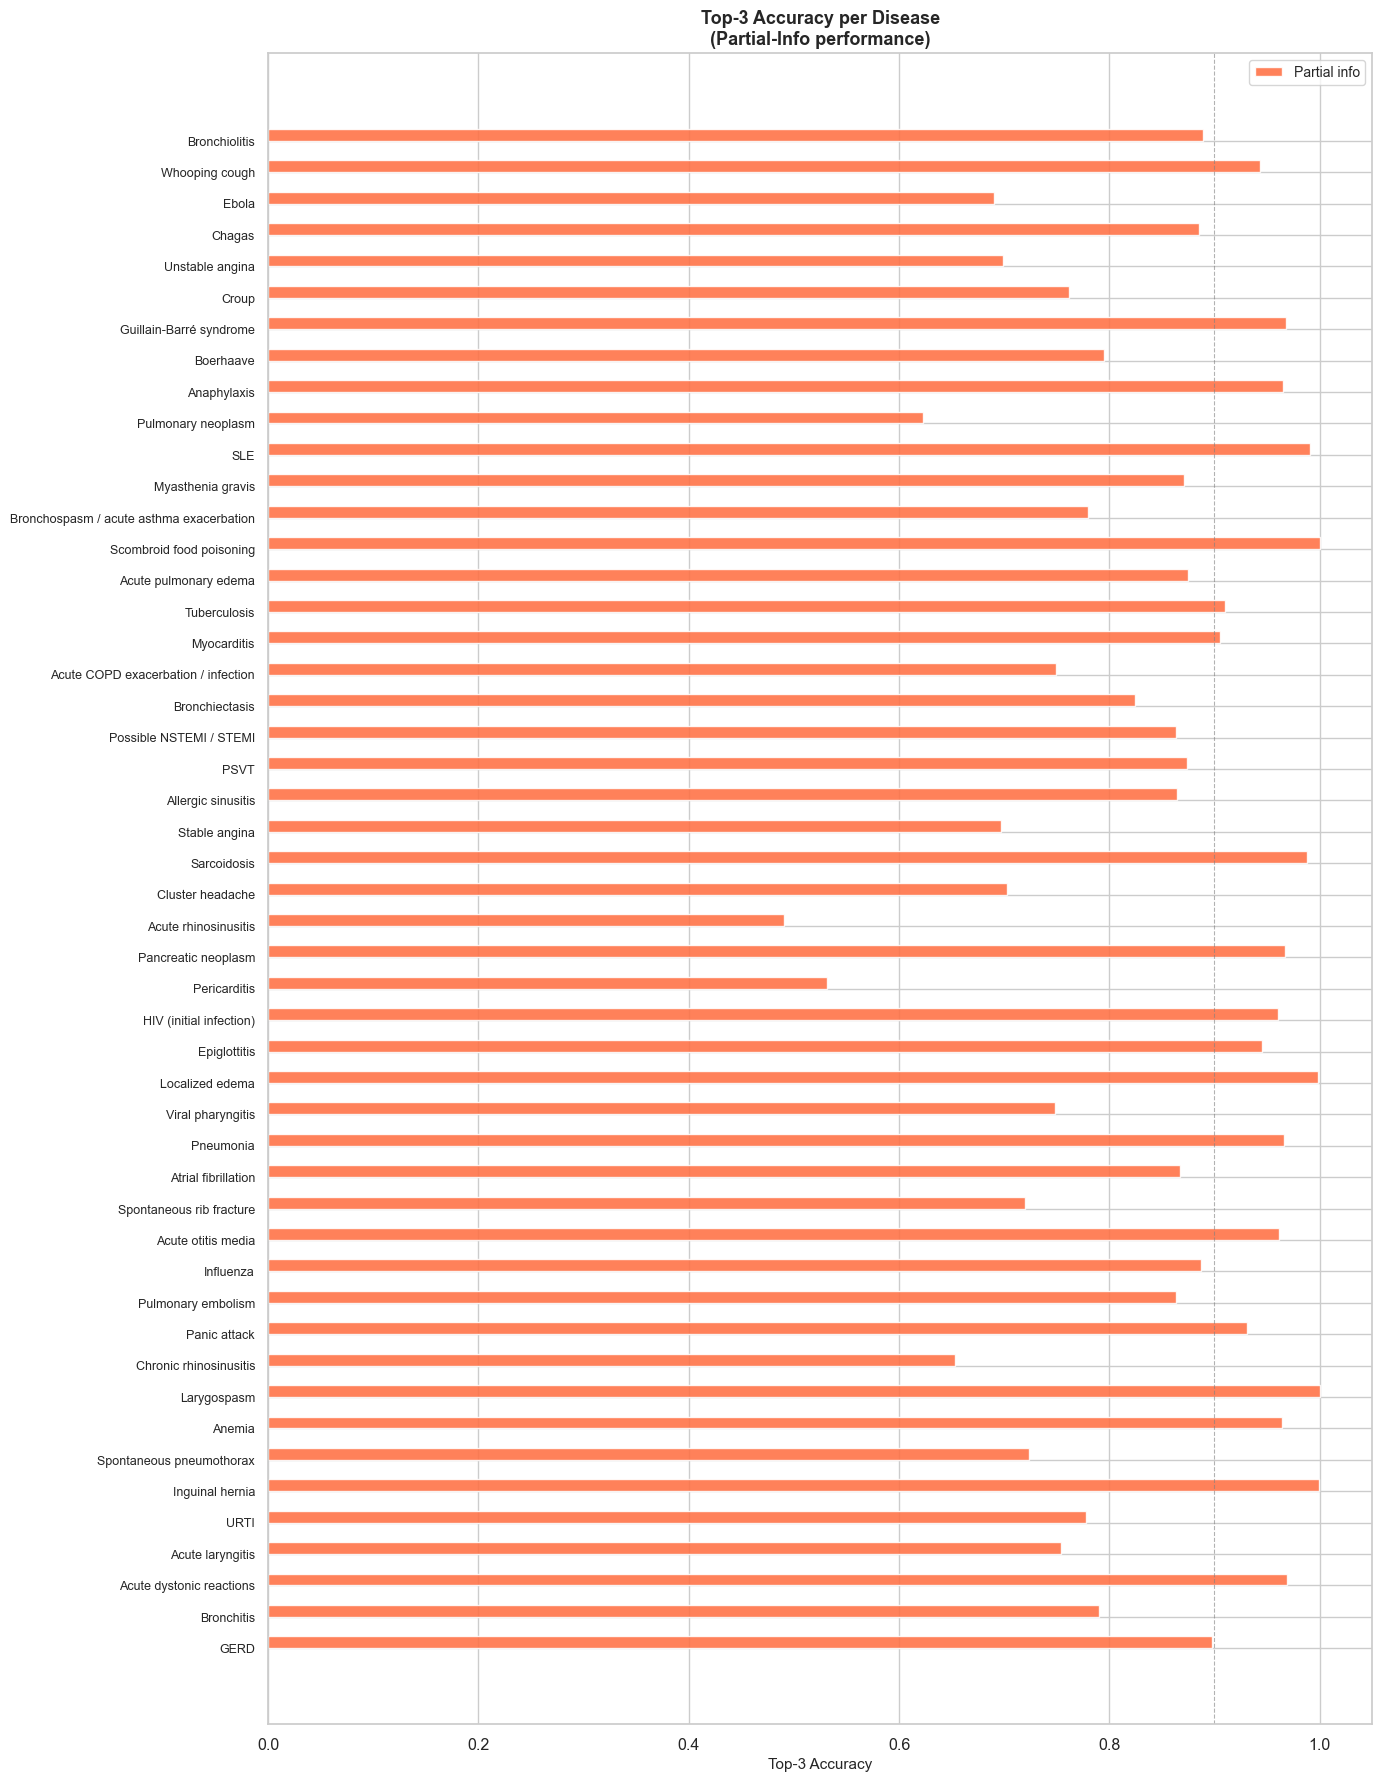

In [9]:
order = partial.loc[partial["top3"] > 0.3, "top3"].index.tolist()

x = np.arange(len(order))
width = 0.38

fig, ax = plt.subplots(figsize=(FIGSIZE_TALL[0], FIGSIZE_TALL[1]))
# ax.barh(x - width/2, full.loc[order, 'top1'],   width, color=FULL_COLOR,    label='Full info',    alpha=0.88)
ax.barh(x + width/2, partial.loc[order, 'top3'], width, color=PARTIAL_COLOR, label='Partial info', alpha=0.88)

ax.set_yticks(x)
ax.set_yticklabels(order, fontsize=9)
ax.set_xlabel('Top-3 Accuracy', fontsize=11)
ax.set_title('Top-3 Accuracy per Disease\n(Partial-Info performance)', fontsize=13, fontweight='bold')
ax.axvline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlim(0, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

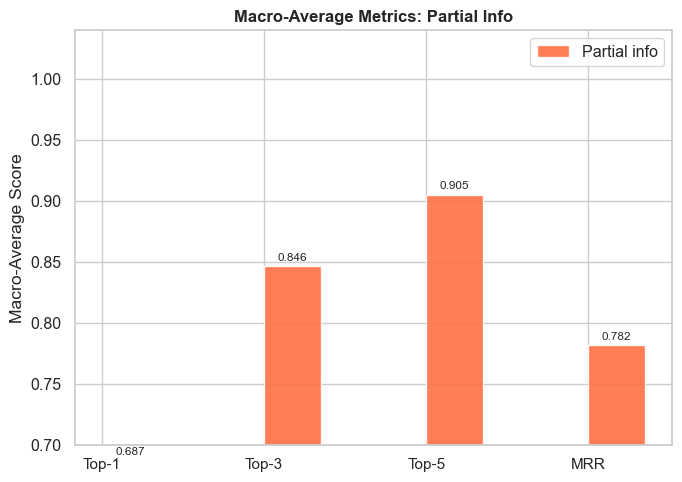

In [10]:
# Macro-average across all diseases
summary = df.groupby('scenario')[['top1','top3','top5','mrr']].mean().T

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(summary))
width = 0.35
# bars1 = ax.bar(x - width/2, summary['full_info'],    width, color=FULL_COLOR,    label='Full info',    alpha=0.9)
bars2 = ax.bar(x + width/2, summary['partial_info'], width, color=PARTIAL_COLOR, label='Partial info', alpha=0.9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(['Top-1', 'Top-3', 'Top-5', 'MRR'], fontsize=11)
ax.set_ylim(0.7, 1.04)
ax.set_ylabel('Macro-Average Score')
ax.set_title('Macro-Average Metrics: Partial Info', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

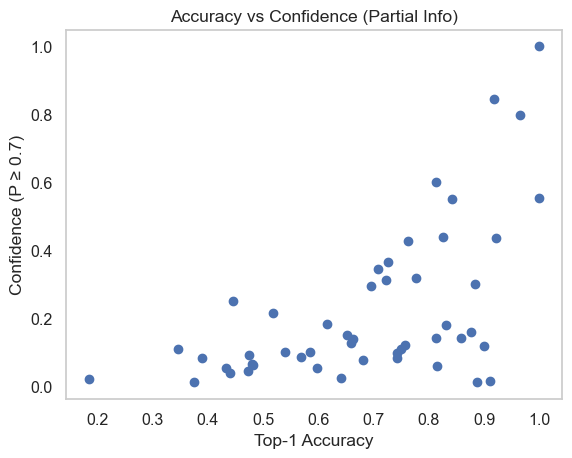

In [11]:
full = df[df["scenario"] == "full_info"]
partial = df[df["scenario"] == "partial_info"]

plt.figure()
plt.scatter(partial["top1"], partial["prob_0.7"])

plt.xlabel("Top-1 Accuracy")
plt.ylabel("Confidence (P ≥ 0.7)")
plt.title("Accuracy vs Confidence (Partial Info)")
plt.grid()
plt.show()

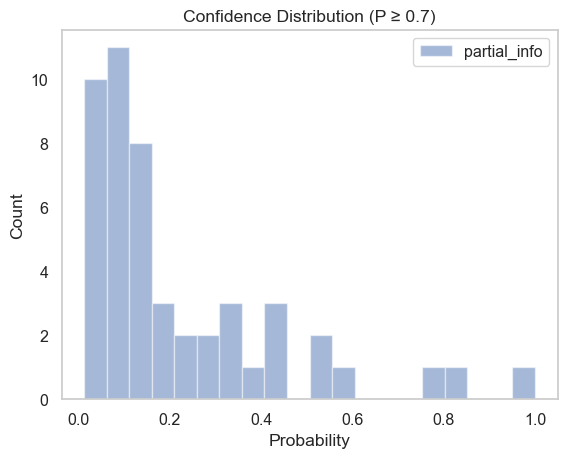

In [12]:
# for scenario in df["scenario"].unique():
subset = df[df["scenario"] == "partial_info"]
plt.hist(subset["prob_0.7"], bins=20, alpha=0.5, label=scenario)

plt.legend()
plt.title("Confidence Distribution (P ≥ 0.7)")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.grid()
plt.show()

TypeError: xticks(): Parameter 'labels' can't be set without setting 'ticks'

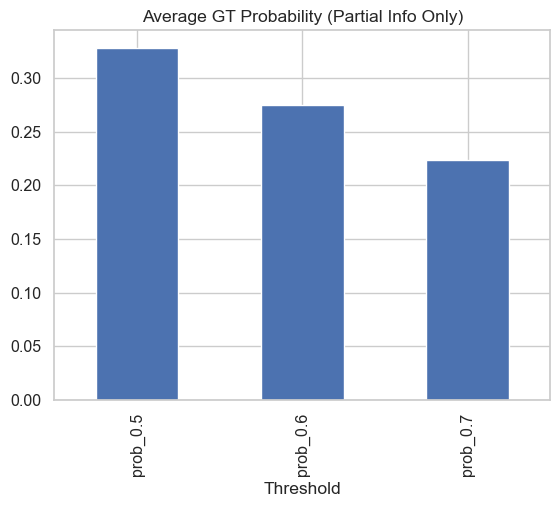

In [13]:
partial_df = df[df["scenario"] == "partial_info"]

avg_probs = partial_df[["prob_0.5", "prob_0.6", "prob_0.7"]].mean()

avg_probs.plot(kind="bar")

plt.title("Average GT Probability (Partial Info Only)")
plt.xlabel("Threshold")
plt.xticks(rotation=0, labels=["P ≥ 0.5", "P ≥ 0.6", "P ≥ 0.7"])
plt.ylabel("Average Fraction Above Threshold")
plt.grid()

plt.show()

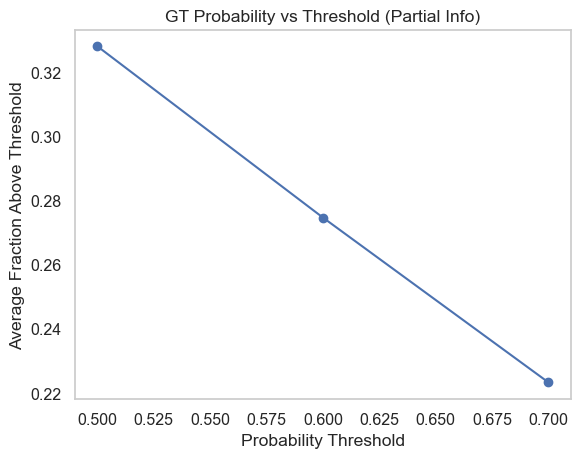

In [14]:
thresholds = [0.5, 0.6, 0.7]
values = partial_df[["prob_0.5", "prob_0.6", "prob_0.7"]].mean().values

plt.figure()

plt.plot(thresholds, values, marker='o')

plt.xlabel("Probability Threshold")
plt.ylabel("Average Fraction Above Threshold")
plt.title("GT Probability vs Threshold (Partial Info)")
plt.grid()

plt.show()

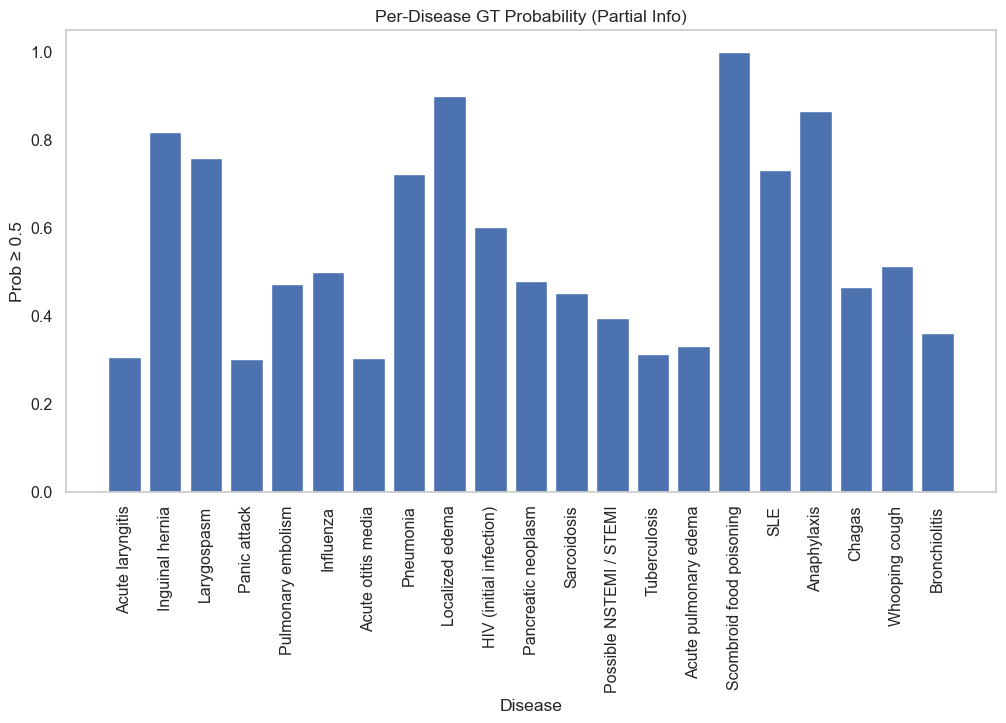

In [15]:
sorted_df = partial_df[partial_df["prob_0.5"] > 0.3]
plt.figure(figsize=(12,6))

plt.bar(sorted_df["disease"], sorted_df["prob_0.5"])

plt.xticks(rotation=90)
plt.xlabel("Disease")
plt.ylabel("Prob ≥ 0.5")
plt.title("Per-Disease GT Probability (Partial Info)")
plt.grid()

plt.show()

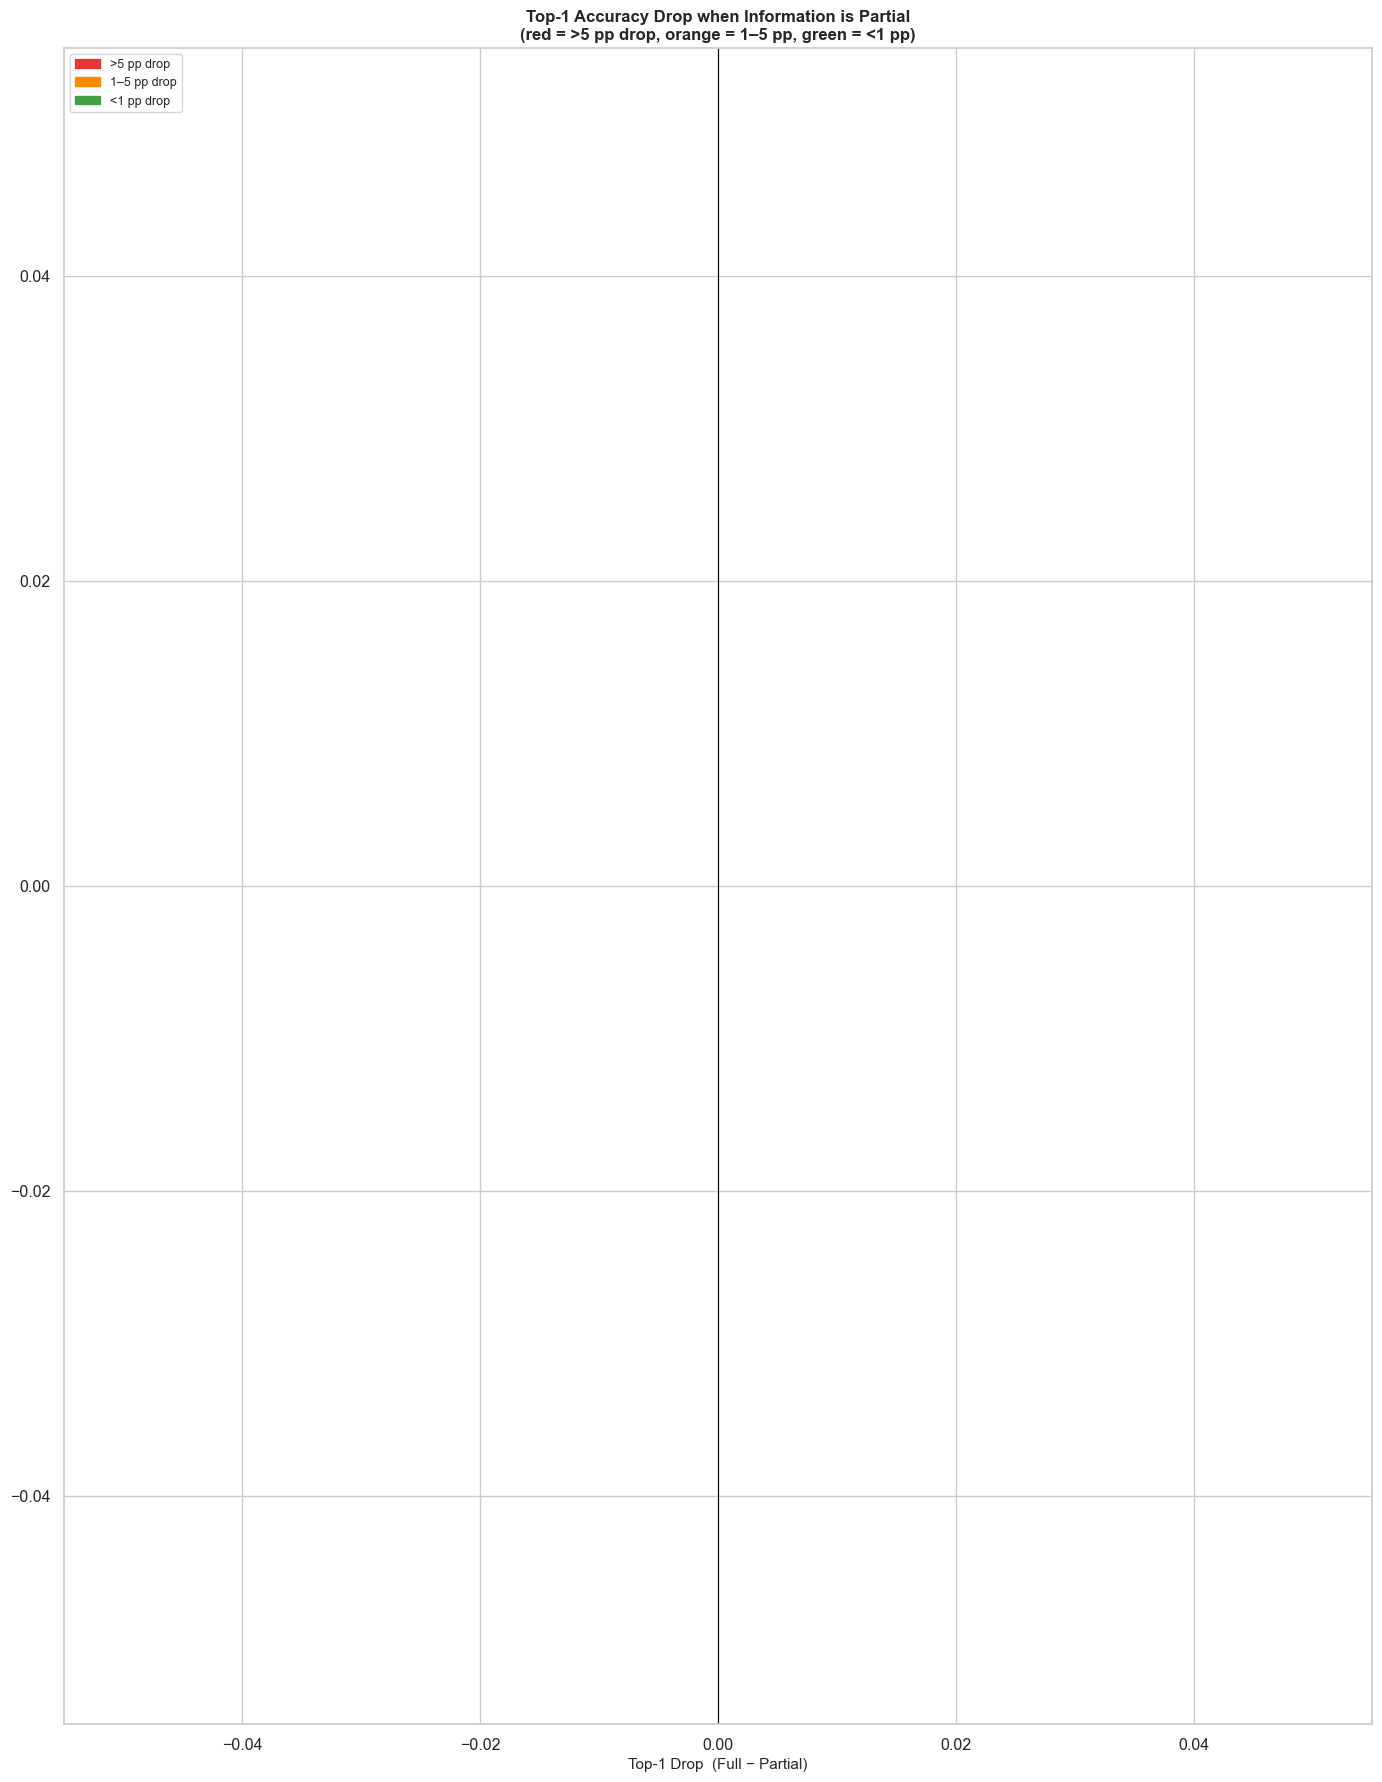

Largest drops:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN


In [16]:
drop = (full['top1'] - partial['top1']).sort_values(ascending=False)

colors = ['#e53935' if v > 0.05 else '#fb8c00' if v > 0.01 else "#e2e9e2"
          for v in drop.values]

fig, ax = plt.subplots(figsize=(FIGSIZE_TALL[0], FIGSIZE_TALL[1]))
drop_values = drop.to_numpy(dtype=float)
ax.barh(drop.index[::-1], drop_values[::-1], color=colors[::-1], alpha=0.88)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Top-1 Drop  (Full − Partial)', fontsize=11)
ax.set_title('Top-1 Accuracy Drop when Information is Partial\n(red = >5 pp drop, orange = 1–5 pp, green = <1 pp)', fontsize=12, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#e53935', label='>5 pp drop'),
    mpatches.Patch(color='#fb8c00', label='1–5 pp drop'),
    mpatches.Patch(color='#43a047', label='<1 pp drop'),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.show()

print('Largest drops:')
print(drop.head(8).to_string())

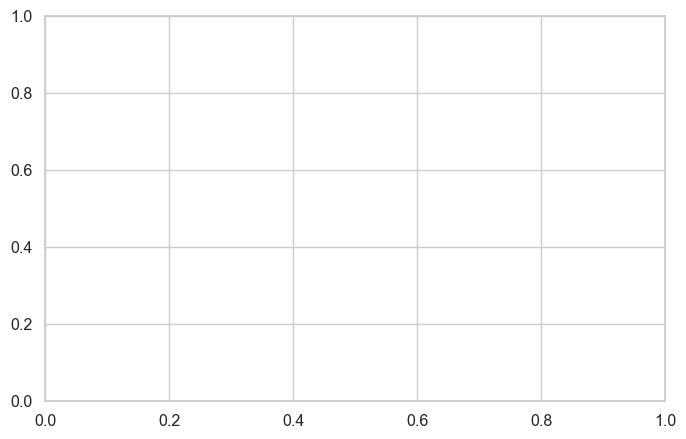

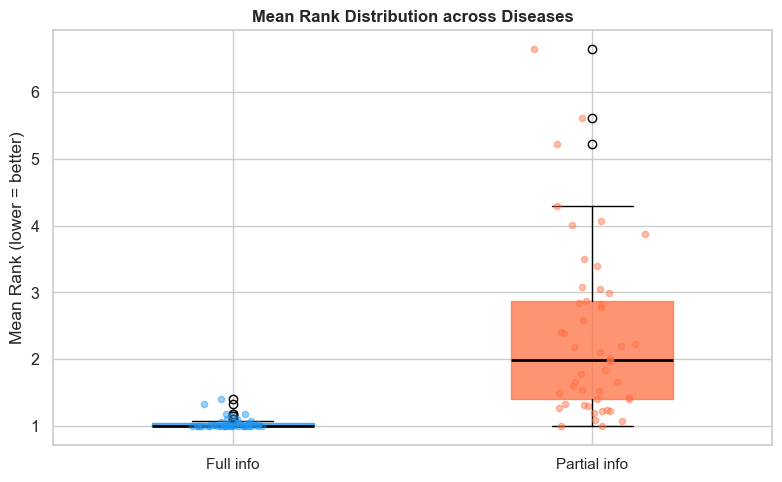

<Figure size 640x480 with 0 Axes>

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [
    full['mean_rank'].values,
    partial['mean_rank'].values
]
fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [
    full['mean_rank'].to_numpy(),
    partial['mean_rank'].to_numpy()
]

bp = ax.boxplot(data_to_plot, patch_artist=True, widths=0.45,
                medianprops=dict(color='black', linewidth=2))

bp['boxes'][0].set_color(FULL_COLOR)
bp['boxes'][0].set_alpha(0.75)
bp['boxes'][1].set_color(PARTIAL_COLOR)
bp['boxes'][1].set_alpha(0.75)

# overlay individual points
for i, vals in enumerate(data_to_plot, 1):
    ax.scatter(np.random.normal(i, 0.06, size=len(vals)), vals,
               alpha=0.45, s=20, zorder=3,
               color=[FULL_COLOR, PARTIAL_COLOR][i-1])

ax.set_xticks([1, 2])
ax.set_xticklabels(['Full info', 'Partial info'], fontsize=11)
ax.set_ylabel('Mean Rank (lower = better)')
ax.set_title('Mean Rank Distribution across Diseases', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
bp['boxes'][0].set_color(FULL_COLOR)
bp['boxes'][0].set_alpha(0.75)
bp['boxes'][1].set_color(PARTIAL_COLOR)
bp['boxes'][1].set_alpha(0.75)

# overlay individual points
for i, vals in enumerate(data_to_plot, 1):
    ax.scatter(np.random.normal(i, 0.06, size=len(vals)), vals,
               alpha=0.45, s=20, zorder=3,
               color=[FULL_COLOR, PARTIAL_COLOR][i-1])

ax.set_xticks([1, 2])
ax.set_xticklabels(['Full info', 'Partial info'], fontsize=11)
ax.set_ylabel('Mean Rank (lower = better)')
ax.set_title('Mean Rank Distribution across Diseases', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

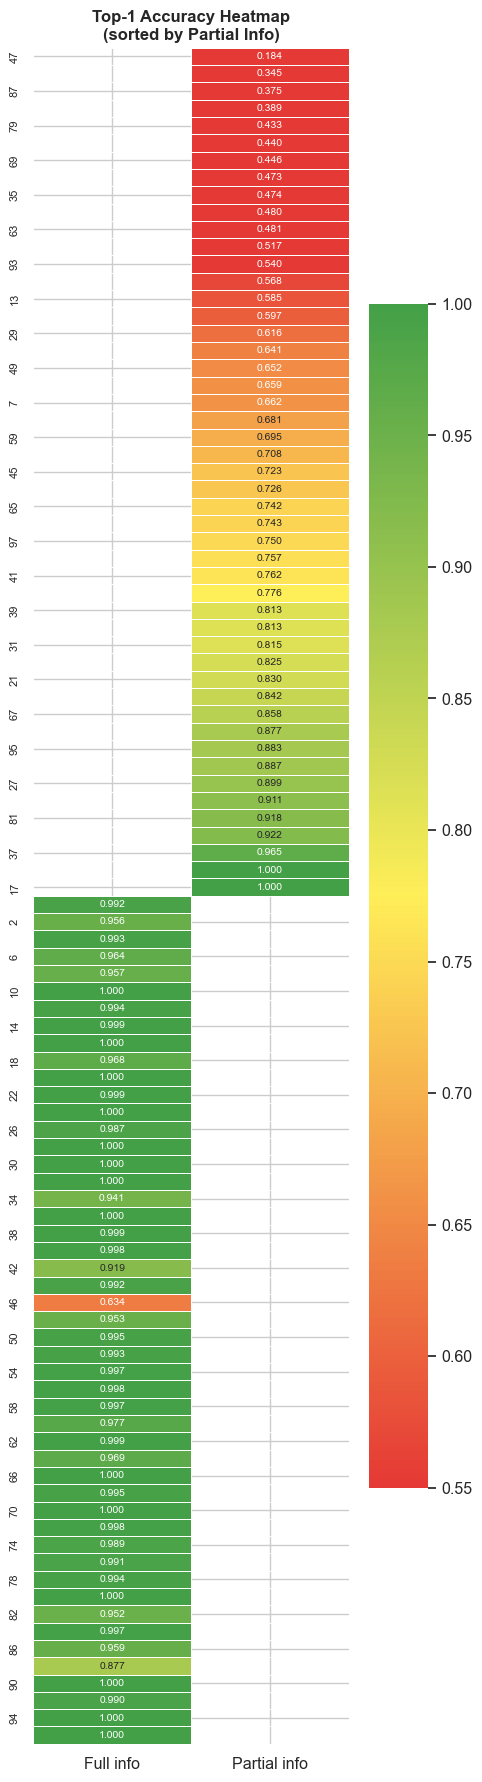

In [18]:
heat_df = pd.DataFrame({
    'Full info':    full['top1'],
    'Partial info': partial['top1']
}).sort_values('Partial info')

cmap = LinearSegmentedColormap.from_list('rg', ['#e53935','#ffee58','#43a047'])

fig, ax = plt.subplots(figsize=(5, FIGSIZE_TALL[1]))
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap=cmap,
            vmin=0.55, vmax=1.0, linewidths=0.4, linecolor='white',
            annot_kws={'size': 7.5}, ax=ax)
ax.set_title('Top-1 Accuracy Heatmap\n(sorted by Partial Info)', fontsize=12, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.show()

KeyError: "None of [Index([47, 89, 87, 43, 79, 19, 69, 61, 35,  9, 63, 53, 93,  3, 13, 73, 29, 75,\n       49, 83,  7, 55, 59, 23, 45, 25, 65, 57, 97,  1, 41, 51, 39, 33, 31, 91,\n       21, 77, 67, 15, 95,  5, 27, 85, 81, 11, 37, 71, 17],\n      dtype='int64')] are in the [index]"

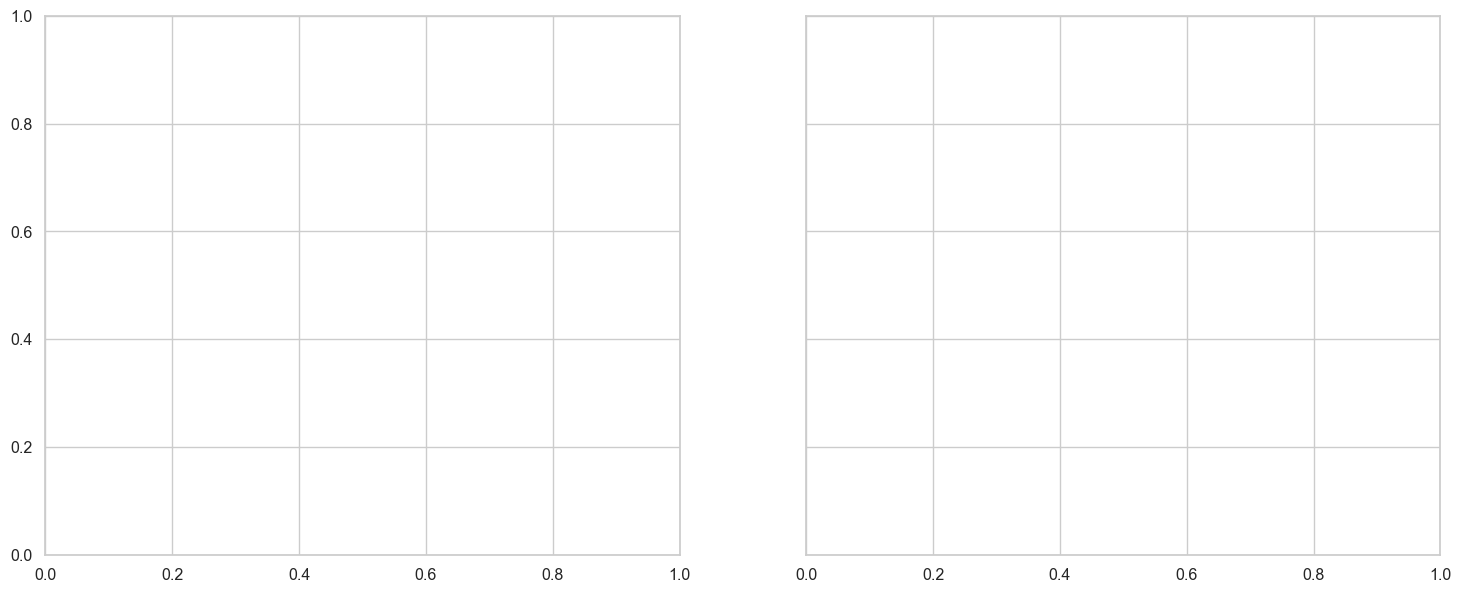

In [19]:
order_partial = partial['top1'].sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE, sharey=True)

for ax, scenario, src, color, title in [
    (axes[0], 'full_info',    full,    FULL_COLOR,    'Full Info'),
    (axes[1], 'partial_info', partial, PARTIAL_COLOR, 'Partial Info'),
]:
    x = np.arange(len(order_partial))
    ax.fill_between(x, src.loc[order_partial,'top5'], alpha=0.15, color=color, label='Top-5')
    ax.fill_between(x, src.loc[order_partial,'top3'], alpha=0.25, color=color, label='Top-3')
    ax.fill_between(x, src.loc[order_partial,'top1'], alpha=0.55, color=color, label='Top-1')
    ax.set_xticks(x)
    ax.set_xticklabels(order_partial, rotation=90, fontsize=7)
    ax.set_ylim(0.5, 1.02)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylabel('Accuracy')

fig.suptitle('Top-K Accuracy Curves (sorted by Partial Top-1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
for label, src in [('Full Info', full), ('Partial Info', partial)]:
    print(f'\n=== {label} ===')
    print(src[['top1','top3','top5','mrr','mean_rank']].describe().round(4).to_string())

# diseases with perfect partial-info Top-1
perfect = partial[partial['top1'] == 1.0].index.tolist()
print(f'\nDiseases with perfect Top-1 (partial info): {len(perfect)}')
print(perfect)

# worst partial-info Top-1
print('\n5 hardest diseases (partial info Top-1):')
print(partial['top1'].sort_values().head(5).to_string())

In [ ]:
import pandas as pd
df_patients = pd.read_csv(".././Data/ddxplus/release_train_patients")

count_per_pathology = df_patients['PATHOLOGY'].value_counts()
print(count_per_pathology)